# 🏥 MedAssist — Fine-tuning no Google Colab
### Tech Challenge IADT — Fase 3 | POSTECH / FIAP

Este notebook realiza o **fine-tuning completo** de um LLM usando:
- **Modelo base:** `unsloth/Phi-3-mini-4k-instruct` (3.8B, eficiente para T4)
- **Técnica:** QLoRA (4-bit) via `unsloth` (2x mais rápido que HuggingFace puro)
- **Dataset:** MedQuAD PT-BR (5.274 pares pergunta/resposta médica)

---
## ⚙️ Pré-requisitos
1. Vá em **Runtime → Change runtime type → T4 GPU**
2. Execute as células em ordem
3. Na **Célula 3**, faça upload do arquivo `medquad_ptbr.jsonl`
4. Ao final, o modelo será salvo no **Google Drive** ou baixado diretamente

**Tempo estimado:** ~45–90 min (T4 gratuita)

---
## 📦 Célula 1 — Verificar GPU e instalar dependências

In [ ]:
# Verifica GPU disponível
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '❌ GPU não encontrada — vá em Runtime > Change runtime type > T4 GPU')

import torch
print(f'\nPyTorch: {torch.__version__}')
print(f'CUDA disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mon May 11 16:42:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Instala unsloth (instalação otimizada para Colab)
# unsloth: fine-tuning 2x mais rápido, 60% menos VRAM que HuggingFace puro
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps trl peft accelerate bitsandbytes -q
print('✅ Dependências instaladas!')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 154.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 27.6 MB/s eta 0:00:00
✅ Dependências instaladas!


---
## 📂 Célula 2 — Montar Google Drive (opcional, para salvar o modelo)

In [ ]:
# Monte o Drive para salvar o modelo treinado (recomendado!)
# Se não quiser usar o Drive, pule esta célula e o modelo será salvo localmente

USE_DRIVE = True  # ← mude para False se não quiser usar o Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_SAVE_PATH = '/content/drive/MyDrive/medassist_model'
    print(f'✅ Drive montado. Modelo será salvo em: {MODEL_SAVE_PATH}')
else:
    MODEL_SAVE_PATH = '/content/medassist_model'
    print(f'⚠️  Sem Drive. Modelo salvo localmente em: {MODEL_SAVE_PATH}')
    print('   (será perdido ao reiniciar o Colab!)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado. Modelo será salvo em: /content/drive/MyDrive/medassist_model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 📊 Célula 3 — Upload e preparação do dataset

In [ ]:
# Opção A: Upload manual do arquivo
from google.colab import files
import os

DATASET_PATH = '/content/medquad_ptbr.jsonl'

if not os.path.exists(DATASET_PATH):
    print('📤 Faça o upload do arquivo medquad_ptbr.jsonl:')
    uploaded = files.upload()
    for fname in uploaded:
        os.rename(fname, DATASET_PATH)
    print(f'✅ Dataset carregado: {DATASET_PATH}')
else:
    print(f'✅ Dataset já existe: {DATASET_PATH}')

# Conta registros
with open(DATASET_PATH) as f:
    n = sum(1 for l in f if l.strip())
print(f'   Total de amostras: {n:,}')

📤 Faça o upload do arquivo medquad_ptbr.jsonl:


✅ Dataset carregado: /content/medquad_ptbr.jsonl


FileNotFoundError: [Errno 2] No such file or directory: '/content/medquad_ptbr.jsonl'

In [ ]:
# Opção B: Carregar do Google Drive (se já tiver lá)
# Descomente se preferir esta opção

DATASET_PATH = '/content/drive/MyDrive/medassist_model/medquad_ptbr.jsonl'
print(f'Dataset: {DATASET_PATH}')

Dataset: /content/drive/MyDrive/medassist_model/medquad_ptbr.jsonl


---
## 🔧 Célula 4 — Pré-processamento do dataset

In [ ]:
import json
import re
import random
from pathlib import Path

# ── Configurações ──────────────────────────────────────────
VAL_SPLIT    = 0.1     # 10% para validação
MAX_SAMPLES  = None    # None = usa tudo; coloque ex. 2000 para teste rápido
RANDOM_SEED  = 42
# ───────────────────────────────────────────────────────────

def clean_text(text):
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def load_and_process(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                r = json.loads(line)
                msgs = r.get('messages', [])
                q = next((m['content'] for m in msgs if m['role'] == 'user'), '')
                a = next((m['content'] for m in msgs if m['role'] == 'assistant'), '')
                if len(q.strip()) >= 5 and len(a.strip()) >= 10:
                    records.append({
                        'question': clean_text(q),
                        'answer':   clean_text(a),
                    })
    return records

print('🔧 Carregando e processando dataset...')
all_records = load_and_process(DATASET_PATH)

if MAX_SAMPLES:
    random.seed(RANDOM_SEED)
    all_records = random.sample(all_records, min(MAX_SAMPLES, len(all_records)))
    print(f'   ⚠️  Limitado a {MAX_SAMPLES} amostras (modo rápido).')

random.seed(RANDOM_SEED)
random.shuffle(all_records)
n_val   = int(len(all_records) * VAL_SPLIT)
train   = all_records[n_val:]
val     = all_records[:n_val]

print(f'✅ Total válidos:  {len(all_records):,}')
print(f'   Treino:         {len(train):,}')
print(f'   Validação:      {len(val):,}')

# Mostra 2 exemplos
print('\n📋 Exemplo de amostra:')
ex = train[0]
print(f'  Pergunta: {ex["question"]}')
print(f'  Resposta: {ex["answer"][:200]}...')

🔧 Carregando e processando dataset...
✅ Total válidos:  5,274
   Treino:         4,747
   Validação:      527

📋 Exemplo de amostra:
  Pergunta: A paralisia espástica hereditária ascendente de início infantil é hereditária?
  Resposta: Essa condição é herdada em um padrão autossômico recessivo, o que significa que ambas as cópias do gene em cada célula apresentam mutações. Os pais de um indivíduo com uma doença autossômica recessiva...


---
## 🤖 Célula 5 — Carregar modelo base com Unsloth

In [ ]:
from unsloth import FastLanguageModel
import torch

# ── Escolha do modelo ──────────────────────────────────────
# Opções recomendadas para T4 (15GB VRAM):
#   'unsloth/Phi-3-mini-4k-instruct'      ← 3.8B, RECOMENDADO, rápido
#   'unsloth/llama-3-8b-Instruct-bnb-4bit' ← 8B, mais capaz, ~60min
#   'unsloth/mistral-7b-instruct-v0.3-bnb-4bit' ← 7B, boa qualidade
#   'unsloth/gemma-2b-it-bnb-4bit'        ← 2B, muito rápido, qualidade menor

MODEL_NAME   = 'unsloth/Phi-3-mini-4k-instruct'  # ← ajuste aqui
MAX_SEQ_LEN  = 1024   # máximo de tokens por amostra
LOAD_IN_4BIT = True   # QLoRA: 4-bit para economizar VRAM
# ───────────────────────────────────────────────────────────

print(f'📦 Carregando {MODEL_NAME}...')
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,       # auto-detecta (float16 na T4)
    load_in_4bit   = LOAD_IN_4BIT,
)
print(f'✅ Modelo carregado!')
print(f'   Parâmetros totais: {sum(p.numel() for p in model.parameters())/1e6:.0f}M')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
📦 Carregando unsloth/Phi-3-mini-4k-instruct...
==((====))==  Unsloth 2026.5.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

✅ Modelo carregado!
   Parâmetros totais: 2009M


---
## 🎯 Célula 6 — Configurar LoRA

In [ ]:
# ── Configurações LoRA ─────────────────────────────────────
LORA_R       = 16    # rank: 8-32 (maior = mais parâmetros treináveis)
LORA_ALPHA   = 32    # escala: geralmente 2x o rank
LORA_DROPOUT = 0.05
# ───────────────────────────────────────────────────────────

model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],
    bias           = 'none',
    use_gradient_checkpointing = 'unsloth',  # economiza VRAM
    random_state   = 42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ LoRA configurado!')
print(f'   Parâmetros treináveis: {trainable/1e6:.2f}M ({100*trainable/total:.2f}% do total)')
print(f'   Parâmetros congelados: {(total-trainable)/1e6:.0f}M')

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.2 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ LoRA configurado!
   Parâmetros treináveis: 29.88M (1.47% do total)
   Parâmetros congelados: 2009M


---
## 📝 Célula 7 — Formatar dataset para fine-tuning

In [ ]:
from datasets import Dataset

SYSTEM_PROMPT = 'Você é um assistente médico especializado. Responda de forma precisa, clara e segura, sempre recomendando consulta médica profissional para decisões clínicas.'

def format_chat(record):
    """
    Formata no estilo ChatML / Instruct — compatível com Phi-3, LLaMA, Mistral.
    """
    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': record['question']},
        {'role': 'assistant', 'content': record['answer']},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {'text': text}

print('🔄 Formatando dataset...')
train_dataset = Dataset.from_list(train).map(format_chat)
val_dataset   = Dataset.from_list(val).map(format_chat)

print(f'✅ Datasets formatados!')
print(f'   Treino:    {len(train_dataset):,} amostras')
print(f'   Validação: {len(val_dataset):,} amostras')
print('\n📋 Exemplo formatado:')
print(train_dataset[0]['text'][:500] + '...')

🔄 Formatando dataset...


Map:   0%|          | 0/4747 [00:00<?, ? examples/s]

Map:   0%|          | 0/527 [00:00<?, ? examples/s]

✅ Datasets formatados!
   Treino:    4,747 amostras
   Validação: 527 amostras

📋 Exemplo formatado:
<|system|>
Você é um assistente médico especializado. Responda de forma precisa, clara e segura, sempre recomendando consulta médica profissional para decisões clínicas.<|end|>
<|user|>
A paralisia espástica hereditária ascendente de início infantil é hereditária?<|end|>
<|assistant|>
Essa condição é herdada em um padrão autossômico recessivo, o que significa que ambas as cópias do gene em cada célula apresentam mutações. Os pais de um indivíduo com uma doença autossômica recessiva carregam, cad...


---
## 🏋️ Célula 8 — Treinamento

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# ── Hiperparâmetros de treinamento ─────────────────────────
# Perfil RÁPIDO (T4 free, ~45 min):  epochs=1, batch=4, grad_accum=4
# Perfil COMPLETO (T4 free, ~90 min): epochs=3, batch=2, grad_accum=8

NUM_EPOCHS          = 1       # ← aumente para 3 se tiver tempo/Colab Pro
BATCH_SIZE          = 4       # por device
GRAD_ACCUM_STEPS    = 4       # effective batch = 4*4 = 16
LEARNING_RATE       = 2e-4
WARMUP_RATIO        = 0.03 # This value will be converted to steps
WEIGHT_DECAY        = 0.01
LOG_STEPS           = 25
SAVE_STEPS          = 200
MAX_STEPS           = -1      # -1 = roda todas as epochs; coloque ex. 100 para teste
# ───────────────────────────────────────────────────────────

training_args = TrainingArguments(
    per_device_train_batch_size   = BATCH_SIZE,
    gradient_accumulation_steps   = GRAD_ACCUM_STEPS,
    warmup_steps                  = int(WARMUP_RATIO * (len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM_STEPS) * NUM_EPOCHS)), # Converted from warmup_ratio
    num_train_epochs              = NUM_EPOCHS,
    max_steps                     = MAX_STEPS,
    learning_rate                 = LEARNING_RATE,
    fp16                          = not is_bfloat16_supported(),
    bf16                          = is_bfloat16_supported(),
    logging_steps                 = LOG_STEPS,
    optim                         = 'adamw_8bit',  # economiza VRAM
    weight_decay                  = WEIGHT_DECAY,
    lr_scheduler_type             = 'cosine',
    seed                          = 42,
    output_dir                    = '/content/drive/MyDrive/MedAssist/checkpoints',
    save_strategy                 = 'steps',
    save_steps                    = SAVE_STEPS,
    save_total_limit              = 2,
    eval_strategy                 = 'steps',
    eval_steps                    = SAVE_STEPS,
    load_best_model_at_end        = True,
    logging_dir                   = '/content/drive/MyDrive/MedAssist/logs',
    report_to                     = 'none',
)

trainer = SFTTrainer(
    model           = model,
    tokenizer       = tokenizer,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    dataset_text_field = 'text',
    max_seq_length  = MAX_SEQ_LEN,
    dataset_num_proc= 2,
    packing         = False,  # False = mais estável com dados médicos
    args            = training_args,
)

# Mostra uso de VRAM antes
gpu_stats = torch.cuda.get_device_properties(0)
used_mb   = round(torch.cuda.memory_reserved() / 1024**2)
total_mb  = round(gpu_stats.total_memory / 1024**2)
print(f'🖥️  GPU: {gpu_stats.name} | VRAM usada: {used_mb}MB / {total_mb}MB')
print(f'\n🚀 Iniciando treinamento...')
print(f'   Epochs: {NUM_EPOCHS} | Batch efetivo: {BATCH_SIZE*GRAD_ACCUM_STEPS}')
print(f'   Total de passos: ~{len(train_dataset)//(BATCH_SIZE*GRAD_ACCUM_STEPS)*NUM_EPOCHS}')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/4747 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/527 [00:00<?, ? examples/s]

🖥️  GPU: NVIDIA L4 | VRAM usada: 2310MB / 22563MB

🚀 Iniciando treinamento...
   Epochs: 1 | Batch efetivo: 16
   Total de passos: ~296


In [ ]:
# ▶️ EXECUTA O TREINAMENTO COM RESUME DE CHECKPOINT

import os

CHECKPOINT_PATH = '/content/drive/MyDrive/MedAssist/checkpoints'

last_checkpoint = None

if os.path.exists(CHECKPOINT_PATH):
    checkpoints = [
        os.path.join(CHECKPOINT_PATH, d)
        for d in os.listdir(CHECKPOINT_PATH)
        if d.startswith('checkpoint-')
    ]

    if checkpoints:
        last_checkpoint = sorted(checkpoints, key=os.path.getmtime)[-1]
        print(f'🔄 Retomando checkpoint: {last_checkpoint}')

if last_checkpoint:
    trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print('🚀 Iniciando treinamento do zero')
    trainer_stats = trainer.train()

# Mostra estatísticas
used_mb_after = round(torch.cuda.memory_reserved() / 1024**2)

print(f'\n✅ Treinamento concluído!')
print(f'   Tempo total:  {trainer_stats.metrics["train_runtime"]:.0f}s ({trainer_stats.metrics["train_runtime"]/60:.1f} min)')
print(f'   Train loss:   {trainer_stats.metrics["train_loss"]:.4f}')
print(f'   VRAM usada:   {used_mb_after}MB / {total_mb}MB')


🔄 Retomando checkpoint: /content/drive/MyDrive/MedAssist/checkpoints/checkpoint-297


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,747 | Num Epochs = 1 | Total steps = 297
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Step,Training Loss,Validation Loss



✅ Treinamento concluído!
   Tempo total:  0s (0.0 min)
   Train loss:   0.0000
   VRAM usada:   2366MB / 22563MB


---
## 📊 Célula 9 — Avaliação qualitativa (teste de respostas)

In [ ]:
from unsloth import FastLanguageModel

# Ativa modo inferência (mais rápido)
FastLanguageModel.for_inference(model)

DISCLAIMER = '\n\n⚠️ Esta resposta é informativa e não substitui avaliação médica profissional.'

def gerar_resposta(pergunta, max_tokens=400):
    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': pergunta},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt',
    ).to('cuda')

    outputs = model.generate(
        input_ids      = inputs,
        max_new_tokens = max_tokens,
        use_cache      = True,
        temperature    = 0.3,
        do_sample      = True,
        top_p          = 0.9,
    )
    # Decodifica apenas os novos tokens gerados
    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    return response.strip() + DISCLAIMER

# Perguntas de teste
perguntas_teste = [
    'Quais são os sintomas da diabetes tipo 2?',
    'O que causa hipertensão arterial?',
    'Como funciona a quimioterapia?',
    'Quais são os fatores de risco para AVC?',
    'O que é leucemia linfoblástica aguda?',
]

print('💬 Testando o modelo fine-tuned:\n')
print('=' * 70)
for i, pergunta in enumerate(perguntas_teste, 1):
    print(f'\n[{i}] ❓ {pergunta}')
    resposta = gerar_resposta(pergunta)
    print(f'    💬 {resposta[:400]}')
    print('-' * 70)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


💬 Testando o modelo fine-tuned:


[1] ❓ Quais são os sintomas da diabetes tipo 2?


Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

    💬 Os sinais e sintomas da diabetes tipo 2 incluem fadiga, sede excessiva, micção frequente, visão turva, perda de peso e visão dupla. A diabetes tipo 2 é frequentemente diagnosticada quando os níveis de glicose no sangue são elevados.

⚠️ Esta resposta é informativa e não substitui avaliação médica profissional.
----------------------------------------------------------------------

[2] ❓ O que causa hipertensão arterial?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

    💬 A quimioterapia funciona matando as células cancerígenas que crescem e se dividem rapidamente. Como as células cancerígenas crescem e se dividem mais rapidamente do que as células normais, elas são mais suscetíveis a danos causados ​​pela quimioterapia. A quimioterapia pode ser usada ​​sozinha ou em combinação com outras terapias, como cirurgia, radioterapia ou medicamentos que visam células cance
----------------------------------------------------------------------

[4] ❓ Quais são os fatores de risco para AVC?


Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    💬 O risco de AVC aumenta com a idade. A maioria dos AVCs ocorre em pessoas com mais de 65 anos. Outros fatores de risco incluem: - Doença cardíaca ou doença arterial. - Diabetes. - Pressão alta. - Tabagismo. - Alcoolismo. - Obesidade. - Ter uma doença autoimune. - Ter uma doença hepática ou renal. - Ter um câncer. - Ter uma doença que causa anemia. - Ter uma doença que causa baixo nível de ferro no 
----------------------------------------------------------------------

[5] ❓ O que é leucemia linfoblástica aguda?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


    💬 A leucemia linfoblástica aguda (LLA) é um tipo de câncer que começa no sistema imunológico. Os glóbulos brancos são as células do sistema imunológico que ajudam o corpo a combater infecções. A LLA ocorre quando as células brancas do sangue (linfócitos) crescem e se multiplicam muito rapidamente. Os linfócitos normais são produzidos no baço, medula óssea e medula espinhal. A LLA começa quando um li
----------------------------------------------------------------------


---
## 💾 Célula 10 — Salvar modelo

In [ ]:
import os

print(f'💾 Salvando modelo em: {MODEL_SAVE_PATH}')
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Salva adaptadores LoRA (pequeno, ~50–200MB)
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Opcional: merge LoRA no modelo base e salva em 16-bit
# (arquivo maior ~7GB, mas mais fácil de usar sem a lib PEFT)
MERGE_MODEL = False  # ← True para merge completo
if MERGE_MODEL:
    merged_path = MODEL_SAVE_PATH + '_merged'
    model.save_pretrained_merged(merged_path, tokenizer, save_method='merged_16bit')
    print(f'✅ Modelo merged salvo em: {merged_path}')

# Lista arquivos salvos
files_saved = list(os.listdir(MODEL_SAVE_PATH))
print(f'\n✅ Arquivos salvos ({len(files_saved)}):')
for f in sorted(files_saved):
    size = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f)) / 1024**2
    print(f'   {f:<40} {size:.1f} MB')

💾 Salvando modelo em: /content/drive/MyDrive/medassist_model


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/medassist_model/tokenizer_config.json.



✅ Arquivos salvos (9):
   README.md                                0.0 MB
   adapter_config.json                      0.0 MB
   adapter_model.safetensors                114.1 MB
   chat_template.jinja                      0.0 MB
   loss_curve.png                           0.0 MB
   medquad_ptbr.jsonl                       4.0 MB
   tokenizer.json                           3.5 MB
   tokenizer.model                          0.5 MB
   tokenizer_config.json                    0.0 MB


---
## 📥 Célula 11 — Download dos adaptadores LoRA (se não usar Drive)

In [ ]:
# Compacta e baixa os adaptadores LoRA (~50–200MB)
# Use isso se não quiser usar o Google Drive

import shutil
from google.colab import files

ZIP_NAME = '/content/medassist_lora_adapters.zip'
shutil.make_archive(
    ZIP_NAME.replace('.zip', ''),
    'zip',
    MODEL_SAVE_PATH
)

size_mb = os.path.getsize(ZIP_NAME) / 1024**2
print(f'📦 ZIP criado: {ZIP_NAME} ({size_mb:.1f} MB)')
print('⬇️  Iniciando download...')
files.download(ZIP_NAME)

📦 ZIP criado: /content/medassist_lora_adapters.zip (107.0 MB)
⬇️  Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📊 Célula 12 — Métricas de treinamento

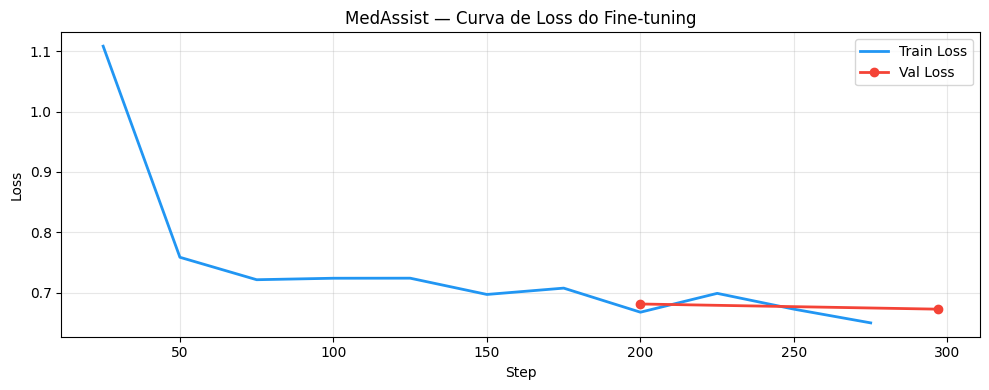

📊 Gráfico salvo em: /content/loss_curve.png

📈 Sumário do treinamento:
   Loss inicial:  1.1085
   Loss final:    0.6497
   Redução:       41.4%
   Val loss final: 0.6724


In [ ]:
import matplotlib.pyplot as plt

# Extrai histórico de loss
log_history = trainer.state.log_history
train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_losses  = [(e['step'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

if train_losses:
    steps_train, losses_train = zip(*train_losses)
    steps_eval,  losses_eval  = zip(*eval_losses) if eval_losses else ([], [])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps_train, losses_train, label='Train Loss', color='#2196F3', linewidth=2)
    if steps_eval:
        ax.plot(steps_eval, losses_eval, label='Val Loss', color='#F44336', linewidth=2, marker='o')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('MedAssist — Curva de Loss do Fine-tuning')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plot_path = '/content/loss_curve.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'📊 Gráfico salvo em: {plot_path}')

    # Salva no Drive também
    if USE_DRIVE:
        shutil.copy(plot_path, MODEL_SAVE_PATH + '/loss_curve.png')

    # Sumário final
    print(f'\n📈 Sumário do treinamento:')
    print(f'   Loss inicial:  {losses_train[0]:.4f}')
    print(f'   Loss final:    {losses_train[-1]:.4f}')
    print(f'   Redução:       {(1 - losses_train[-1]/losses_train[0])*100:.1f}%')
    if losses_eval:
        print(f'   Val loss final: {losses_eval[-1]:.4f}')
else:
    print('⚠️  Histórico de loss não disponível.')

---
## Celula 12b -- Exportar GGUF para Ollama (MODO 3 -- sem GPU local)

Esta celula **funde** os adaptadores LoRA ao modelo base e exporta no formato **GGUF quantizado**,
compativel com o Ollama. Isso permite rodar o **seu proprio modelo fine-tunado** localmente
**sem GPU**, da mesma forma que o gemma3:4b no MODO 2.

**Por que fazer isso?**
- O MODO 2 usa o gemma3:4b (modelo generico, sem especializacao medica)
- O MODO 3 usa o **Phi-3-mini que voce treinou** -- com fine-tuning no MedQuAD PT-BR
- Ambos rodam via Ollama local, sem GPU, sem API key, offline

> Execute esta celula **logo apos a Celula 10 (Salvar modelo)**, ainda com GPU ativa.
> O arquivo gerado (~2.2 GB) sera baixado na Celula 12c e registrado no Ollama local.


In [ ]:
# Celula 12b -- Exportar modelo fine-tunado para GGUF (Ollama MODO 3)
# Executa no Colab com GPU ativa.
# Funde LoRA + Phi-3-mini e gera um .gguf quantizado que roda no Ollama SEM GPU.
#
# Quantizacoes disponiveis:
#   q4_k_m  ->  ~2.2 GB -- melhor balanco qualidade/tamanho  <- RECOMENDADO
#   q8_0    ->  ~4.0 GB -- maior qualidade, arquivo maior
#   f16     ->  ~7.5 GB -- sem perda de qualidade, requer mais RAM

import os

GGUF_QUANT = 'q4_k_m'          # quantizacao recomendada
GGUF_DIR   = '/content/drive/MyDrive/medassist/gguf'   # pasta de saida no Colab

os.makedirs(GGUF_DIR, exist_ok=True)

print('Fundindo adaptadores LoRA no modelo base...')
print('Phi-3-mini (3.8B) + seus adaptadores LoRA treinados no MedQuAD PT-BR')
print('Isso pode levar 3-8 minutos...')

# Unsloth faz a fusao LoRA + exportacao GGUF em um unico passo
model.save_pretrained_gguf(
    GGUF_DIR,
    tokenizer,
    quantization_method=GGUF_QUANT,
)

# Lista arquivo(s) gerado(s)
gguf_files = [f for f in os.listdir(GGUF_DIR) if f.endswith('.gguf')]
print('\n Exportacao concluida!')
for f in gguf_files:
    size_gb = os.path.getsize(os.path.join(GGUF_DIR, f)) / 1024**3
    print(f'  {GGUF_DIR}/{f}  ({size_gb:.2f} GB)')

# Salva copia no Drive se montado
if USE_DRIVE and gguf_files:
    import shutil
    drive_gguf = f'/content/drive/MyDrive/medassist/{gguf_files[0]}'
    os.makedirs(os.path.dirname(drive_gguf), exist_ok=True)
    shutil.copy2(os.path.join(GGUF_DIR, gguf_files[0]), drive_gguf)
    print(f'  Copia salva no Drive: {drive_gguf}')

print('\nProximo passo: execute a Celula 12c para baixar o arquivo.')


Fundindo adaptadores LoRA no modelo base...
Phi-3-mini (3.8B) + seus adaptadores LoRA treinados no MedQuAD PT-BR
Isso pode levar 3-8 minutos...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/medassist/gguf/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/medassist/gguf.


...


Unsloth: Preparing safetensor model files:  50%|█████     | 1/2 [00:20<00:20, 20.15s/it]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:32<00:00, 16.06s/it]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:55<00:00, 27.76s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/medassist/gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/medassist/gguf_gguf/phi-3-mini-4k-instruct.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/drive/MyDrive/medassist/gguf_gguf/phi-3-mini-4k-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/drive/MyDrive/medassist/gguf_gguf/phi-3-mini-4k-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /content/drive/MyDrive/medassist/gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/drive/MyDrive/medassist/gguf_gguf/Modelfile

 Exportacao concluida!

Proximo passo: execute a Celula 12c para baixar o arquivo.


---
## Celula 12c -- Download do GGUF + instrucoes para registro no Ollama (MODO 3)


In [ ]:
# Celula 12c -- Baixar o arquivo GGUF e exibir instrucoes de registro no Ollama
# Inicia o download do .gguf para sua maquina (~2.2 GB com q4_k_m).

import os
from google.colab import files as colab_files

GGUF_DIR   = '/content/drive/MyDrive/medassist/gguf_gguf'   # Re-definido aqui para garantir que esteja acessível

gguf_files = [f for f in os.listdir(GGUF_DIR) if f.endswith('.gguf')]

if not gguf_files:
    print('Nenhum arquivo .gguf encontrado. Execute a Celula 12b primeiro.')
else:
    gguf_path = os.path.join(GGUF_DIR, gguf_files[0])
    size_gb   = os.path.getsize(gguf_path) / 1024**3
    print(f'Arquivo: {gguf_path}  ({size_gb:.2f} GB)')
    print('Iniciando download... (pode levar alguns minutos)')
    colab_files.download(gguf_path)

    print("""

PROXIMOS PASSOS -- execute no seu terminal local (nao no Colab)
================================================================

1. Mover o arquivo para o projeto:

   Windows (PowerShell):
   mkdir outputs\\gguf
   move $env:USERPROFILE\\Downloads\\phi3-medassist-Q4_K_M.gguf outputs\\gguf\\phi3-medassist.gguf

   Mac/Linux:
   mkdir -p outputs/gguf
   mv ~/Downloads/phi3-medassist-Q4_K_M.gguf outputs/gguf/phi3-medassist.gguf

2. Criar o Modelfile (Mac/Linux):
   cat > outputs/gguf/Modelfile << 'EOF'
   FROM ./phi3-medassist.gguf
   SYSTEM "Voce e um assistente medico especializado. Responda de forma precisa
   e em portugues. Recomende sempre consulta com profissional de saude."
   PARAMETER temperature 0.3
   PARAMETER num_ctx 2048
   EOF

   Windows (PowerShell) -- salve o arquivo outputs\\gguf\\Modelfile com conteudo:
   FROM ./phi3-medassist.gguf
   SYSTEM "Voce e um assistente medico especializado..."
   PARAMETER temperature 0.3
   PARAMETER num_ctx 2048

3. Registrar no Ollama:
   cd outputs/gguf
   ollama create phi3-medassist -f Modelfile
   ollama list     # deve aparecer phi3-medassist

4. Testar:
   ollama run phi3-medassist "Quais sao os sintomas do diabetes tipo 2?"

5. Configurar o .env do projeto:
   LLM_BACKEND=openai
   OPENAI_BASE_URL=http://localhost:11434/v1
   OPENAI_API_KEY=ollama
   OPENAI_MODEL=phi3-medassist

   Ou: selecione MODO 3 no modal 'Configurar Backend' da interface web
   http://localhost:8080

COMPARATIVO DOS MODOS
=====================
MODO 1: OpenAI gpt-4o-mini    -> rapido, requer API key, nao e seu modelo
MODO 2: Ollama gemma3:4b      -> local, sem custo, modelo generico + RAG
MODO 3: Ollama phi3-medassist -> local, sem custo, SEU MODELO treinado + RAG
""")

Arquivo: /content/drive/MyDrive/medassist/gguf_gguf/phi-3-mini-4k-instruct.Q4_K_M.gguf  (2.16 GB)
Iniciando download... (pode levar alguns minutos)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



PROXIMOS PASSOS -- execute no seu terminal local (nao no Colab)

1. Mover o arquivo para o projeto:

   Windows (PowerShell):
   mkdir outputs\gguf
   move $env:USERPROFILE\Downloads\phi3-medassist-Q4_K_M.gguf outputs\gguf\phi3-medassist.gguf

   Mac/Linux:
   mkdir -p outputs/gguf
   mv ~/Downloads/phi3-medassist-Q4_K_M.gguf outputs/gguf/phi3-medassist.gguf

2. Criar o Modelfile (Mac/Linux):
   cat > outputs/gguf/Modelfile << 'EOF'
   FROM ./phi3-medassist.gguf
   SYSTEM "Voce e um assistente medico especializado. Responda de forma precisa
   e em portugues. Recomende sempre consulta com profissional de saude."
   PARAMETER temperature 0.3
   PARAMETER num_ctx 2048
   EOF

   Windows (PowerShell) -- salve o arquivo outputs\gguf\Modelfile com conteudo:
   FROM ./phi3-medassist.gguf
   SYSTEM "Voce e um assistente medico especializado..."
   PARAMETER temperature 0.3
   PARAMETER num_ctx 2048

3. Registrar no Ollama:
   cd outputs/gguf
   ollama create phi3-medassist -f Modelfile
   o

---
## 🔄 Célula 13 — Como usar o modelo treinado no projeto local

Após baixar os adaptadores LoRA, integre ao projeto MedAssist assim:

In [ ]:
# Este bloco e apenas documentacao -- nao executa no Colab

INSTRUCOES = '''
=====================================================
  COMO USAR O MODELO TREINADO NO PROJETO LOCAL
=====================================================

OPCAO A -- MODO 3 (RECOMENDADO): Ollama + GGUF
------------------------------------------------
  1. Execute as Celulas 12b e 12c para exportar e baixar o GGUF
  2. Registre no Ollama:
       cd outputs/gguf
       ollama create phi3-medassist -f Modelfile
  3. Configure o .env:
       OPENAI_BASE_URL=http://localhost:11434/v1
       OPENAI_MODEL=phi3-medassist
  4. python web_app.py --> http://localhost:8080

  Resultado: seu modelo fine-tunado rodando localmente,
  sem GPU, sem API key, integrado ao RAG MedQuAD.

OPCAO B -- Adaptadores LoRA direto em RAM (requer GPU)
--------------------------------------------------------
  1. Baixe os adaptadores LoRA (Celula 11)
  2. Coloque em: medassist/outputs/model/
  3. Configure o local_server.py (requer ~8 GB VRAM)
  4. python local_server.py --> http://localhost:8000/v1
  5. Configure o .env:
       OPENAI_BASE_URL=http://localhost:8000/v1
       OPENAI_MODEL=phi3-medassist-lora
=====================================================
'''
print(INSTRUCOES)


---
## ✅ Checklist de conclusão

Após executar todas as células, verifique:

- [ ] GPU T4 ativa (Célula 1 mostra `CUDA disponível: True`)
- [ ] Dataset carregado com **5.274 amostras** (Célula 3)
- [ ] Treinamento concluído sem erros (Célula 8)
- [ ] Train loss decrescente (Célula 12 — gráfico)
- [ ] Respostas médicas coerentes em português (Célula 9)
- [ ] Modelo salvo no Drive ou baixado (Células 10/11)

---

**Próximo passo:** Integre os adaptadores LoRA ao projeto local (`medassist/outputs/model/`) e execute a Fase 3 (LangChain + LangGraph).